In [2]:
import ibis
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import t as student_t
from matplotlib.ticker import PercentFormatter
from datetime import date

In [4]:

possible_files = [
    Path("monthly_returns.csv"),
    Path("monthly_returns(1).csv")
]

DATA_PATH = next((p for p in possible_files if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find monthly_returns.csv or monthly_returns(1).csv "
        "in the same folder as this notebook."
    )

print("Using file:", DATA_PATH)

# Connect Ibis to DuckDB
con = ibis.duckdb.connect()

# Read the full return dataset
returns_raw = con.read_csv(str(DATA_PATH))

# Make sure Date is treated as a date
returns_raw = returns_raw.mutate(
    Date=returns_raw.Date.cast("date")
)

# DROP SEPTEMBER 2026 AND ANY LATER DATE FROM THE ENTIRE DATASET
returns_clean = (
    returns_raw
    .filter(returns_raw.Date <= ibis.date(2026, 8, 31))
    .order_by("Date")
)

# Only after filtering the whole dataset, select Part 2 variables
part2 = returns_clean.select(
    "Date",
    "NVDA",
    "^GSPC"
)

Using file: monthly_returns.csv


In [5]:
arrow_data = part2.to_pyarrow()

dates = np.array(
    arrow_data["Date"].to_pylist(),
    dtype=object
)

nvda = np.array(
    arrow_data["NVDA"].to_pylist(),
    dtype=float
)

market = np.array(
    arrow_data["^GSPC"].to_pylist(),
    dtype=float
)

# -------------------------
# DATA VALIDATION
# -------------------------

print("Number of observations:", len(dates))
print("First date:", dates[0])
print("Last date:", dates[-1])

# Expected sample checks
assert len(dates) == 199, "Expected 199 monthly returns after removing Sep 2026."
assert dates[0] == date(2010, 2, 28), "Unexpected starting date."
assert dates[-1] == date(2026, 8, 31), "Unexpected ending date."

# Check for missing / infinite values
assert np.all(np.isfinite(nvda)), "NVDA contains missing or non-finite values."
assert np.all(np.isfinite(market)), "^GSPC contains missing or non-finite values."

# Check that every observation moves forward exactly one calendar month
month_number = np.array(
    [d.year * 12 + d.month for d in dates]
)

assert np.all(np.diff(month_number) == 1), "There is a missing month in the series."

print("All data checks passed.")

Number of observations: 199
First date: 2010-02-28
Last date: 2026-08-31
All data checks passed.


# Part 2 (A)

In [6]:
def expanding_volatility(series, minimum_obs=12):
    """
    Sample standard deviation using all observations
    available up to each date.

    Returns NaN until minimum_obs observations exist.
    """
    
    result = np.full(len(series), np.nan)

    for i in range(len(series)):
        window = series[:i + 1]
        valid = window[np.isfinite(window)]

        if len(valid) >= minimum_obs:
            result[i] = np.std(valid, ddof=1)

    return result


def rolling_volatility(series, window_size=12):
    """
    Sample standard deviation using exactly the most
    recent 12 calendar-month observations.

    If fewer than 12 observations are valid, the window
    is skipped.
    """
    
    result = np.full(len(series), np.nan)

    for i in range(window_size - 1, len(series)):
        window = series[i - window_size + 1:i + 1]
        valid = window[np.isfinite(window)]

        if len(valid) == window_size:
            result[i] = np.std(valid, ddof=1)

    return result

In [7]:
# NVDA volatility
nvda_vol_expanding = expanding_volatility(
    nvda,
    minimum_obs=12
)

nvda_vol_rolling = rolling_volatility(
    nvda,
    window_size=12
)

# S&P 500 volatility
market_vol_expanding = expanding_volatility(
    market,
    minimum_obs=12
)

market_vol_rolling = rolling_volatility(
    market,
    window_size=12
)

print("Final NVDA expanding volatility:",
      round(nvda_vol_expanding[-1], 4))

print("Final NVDA 12-month rolling volatility:",
      round(nvda_vol_rolling[-1], 4))

print("Final S&P 500 expanding volatility:",
      round(market_vol_expanding[-1], 4))

print("Final S&P 500 12-month rolling volatility:",
      round(market_vol_rolling[-1], 4))

Final NVDA expanding volatility: 0.1278
Final NVDA 12-month rolling volatility: 0.0785
Final S&P 500 expanding volatility: 0.0415
Final S&P 500 12-month rolling volatility: 0.0383


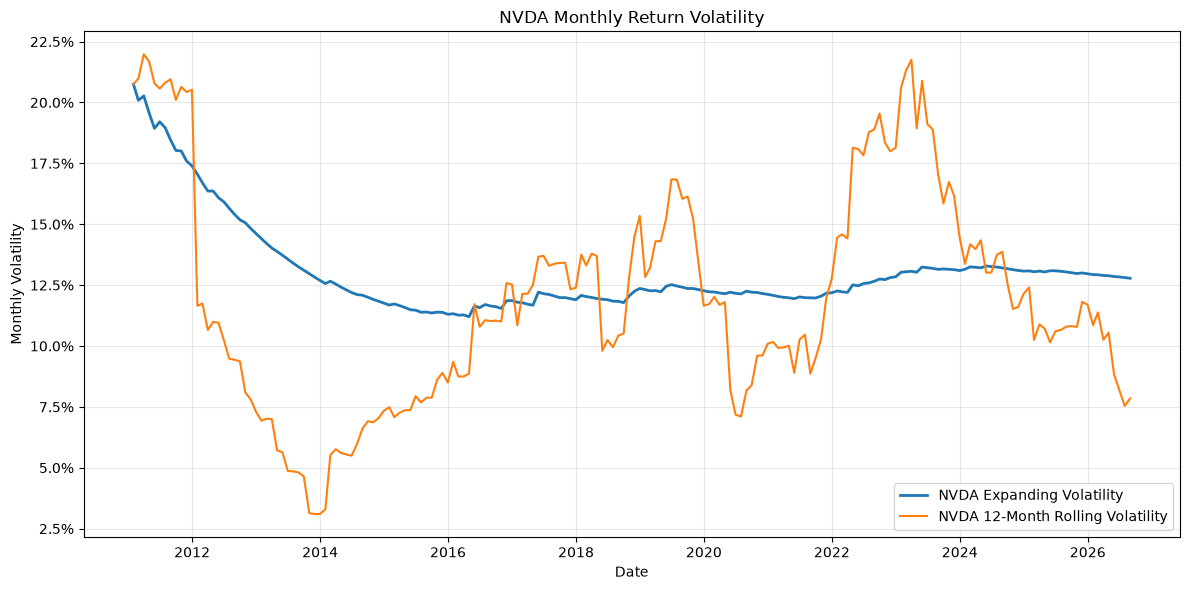

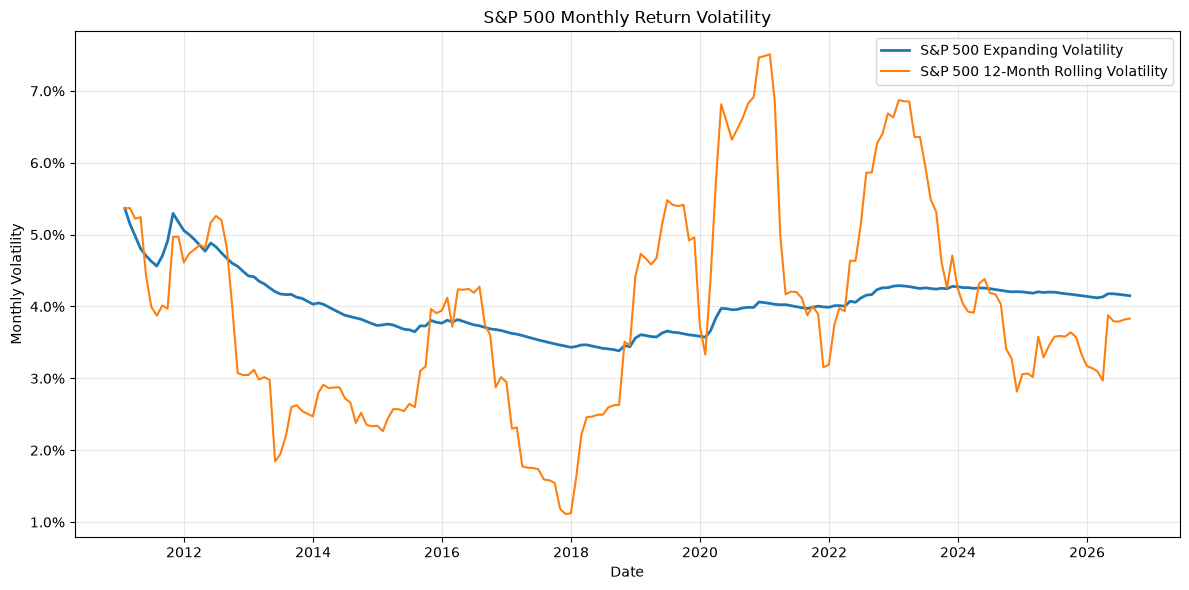

In [ ]:

# NVDA VOLATILITY
# plot 2a

plt.figure(figsize=(12, 6))

plt.plot(
    dates,
    nvda_vol_expanding,
    label="NVDA Expanding Volatility",
    linewidth=2
)

plt.plot(
    dates,
    nvda_vol_rolling,
    label="NVDA 12-Month Rolling Volatility",
    linewidth=1.5
)

plt.title("NVDA Monthly Return Volatility")
plt.xlabel("Date")
plt.ylabel("Monthly Volatility")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# S&P 500 VOLATILITY


plt.figure(figsize=(12, 6))

plt.plot(
    dates,
    market_vol_expanding,
    label="S&P 500 Expanding Volatility",
    linewidth=2
)

plt.plot(
    dates,
    market_vol_rolling,
    label="S&P 500 12-Month Rolling Volatility",
    linewidth=1.5
)

plt.title("S&P 500 Monthly Return Volatility")
plt.xlabel("Date")
plt.ylabel("Monthly Volatility")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

For NVDA and the S&P 500 Index, the 12-month rolling volatility estimates fluctuate much more widely than the estimates based on an extended window. NVDA’s rolling volatility fluctuated particularly significantly during the sample period. It decreased to approximately 3% to 5% between 2013 and 2014, rose sharply between 2019 and 2020, and improved to more than 20% from 2022 to 2023. Conversely, NVDA’s expanded-window volatility gradually leveled off and stabilized at around 12%. The S&P 500 Index follows the same pattern. Rolling volatility reacts strongly to periods of heightened market uncertainty, while the extended-window estimates remain relatively stable at around 4% toward the end of the sample period.

There are two reasons why rolling estimates owns greater volatility. First, each rolling estimate uses only 12 monthly observations, making it more susceptible to sampling error and the impact of individual extreme returns. Second, the rolling window continuously adds the most recent observations and removes the oldest ones, reacting rapidly to changes in the recent volatility environment. In contrast, the extended estimates use all available observations up to each date, so the impact of individual observations diminishes as the sample size increases. As a result, the extended series reflects the longer-term average volatility, while the rolling series is more sensitive to short-term changes in risk.

In [9]:
#Part b
def ols_beta_ci(stock_returns, market_returns):
  

    valid = (
        np.isfinite(stock_returns)
        & np.isfinite(market_returns)
    )

    y = stock_returns[valid]
    x = market_returns[valid]

    n = len(y)

    if n < 3:
        return {
            "n": n,
            "alpha": np.nan,
            "beta": np.nan,
            "se_beta": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan
        }

    x_mean = np.mean(x)
    y_mean = np.mean(y)

    x_dev = x - x_mean
    y_dev = y - y_mean

    sxx = np.sum(x_dev ** 2)

    if sxx == 0:
        return {
            "n": n,
            "alpha": np.nan,
            "beta": np.nan,
            "se_beta": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan
        }


    beta = np.sum(x_dev * y_dev) / sxx
    alpha = y_mean - beta * x_mean


    fitted = alpha + beta * x
    residuals = y - fitted


    sse = np.sum(residuals ** 2)
    residual_variance = sse / (n - 2)

    se_beta = np.sqrt(residual_variance / sxx)

    t_critical = student_t.ppf(
        0.975,
        df=n - 2
    )

    ci_low = beta - t_critical * se_beta
    ci_high = beta + t_critical * se_beta

    return {
        "n": n,
        "alpha": alpha,
        "beta": beta,
        "se_beta": se_beta,
        "ci_low": ci_low,
        "ci_high": ci_high
    }

In [ ]:
n = len(dates)


rolling_beta = np.full(n, np.nan)
rolling_ci_low = np.full(n, np.nan)
rolling_ci_high = np.full(n, np.nan)

expanding_beta = np.full(n, np.nan)
expanding_ci_low = np.full(n, np.nan)
expanding_ci_high = np.full(n, np.nan)


for i in range(n):

  
    if i >= 11:

        y_window = nvda[i - 11:i + 1]
        x_window = market[i - 11:i + 1]

        valid_count = np.sum(
            np.isfinite(y_window)
            & np.isfinite(x_window)
        )

        if valid_count == 12:
            result = ols_beta_ci(
                y_window,
                x_window
            )

            rolling_beta[i] = result["beta"]
            rolling_ci_low[i] = result["ci_low"]
            rolling_ci_high[i] = result["ci_high"]


   
    y_expanding = nvda[:i + 1]
    x_expanding = market[:i + 1]

    valid_count = np.sum(
        np.isfinite(y_expanding)
        & np.isfinite(x_expanding)
    )

    if valid_count >= 24:
        result = ols_beta_ci(
            y_expanding,
            x_expanding
        )

        expanding_beta[i] = result["beta"]
        expanding_ci_low[i] = result["ci_low"]
        expanding_ci_high[i] = result["ci_high"]

In [11]:
full_sample = ols_beta_ci(
    nvda,
    market
)

print("Full-sample NVDA beta:",
      round(full_sample["beta"], 4))

print("Full-sample beta standard error:",
      round(full_sample["se_beta"], 4))

print(
    "Full-sample 95% CI:",
    f"[{full_sample['ci_low']:.4f}, "
    f"{full_sample['ci_high']:.4f}]"
)

Full-sample NVDA beta: 1.7144
Full-sample beta standard error: 0.1823
Full-sample 95% CI: [1.3549, 2.0739]


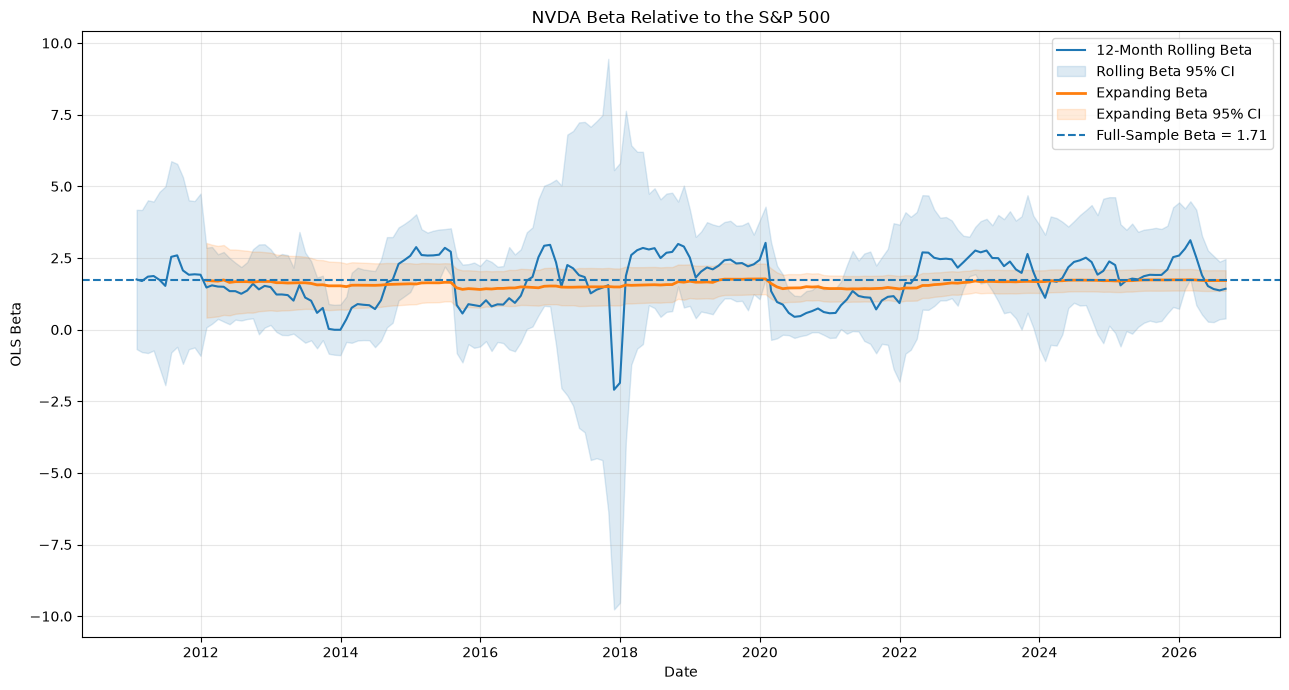

In [ ]:
plt.figure(figsize=(13, 7))


rolling_line, = plt.plot(
    dates,
    rolling_beta,
    label="12-Month Rolling Beta",
    linewidth=1.5
)

plt.fill_between(
    dates,
    rolling_ci_low,
    rolling_ci_high,
    color=rolling_line.get_color(),
    alpha=0.15,
    label="Rolling Beta 95% CI"
)


expanding_line, = plt.plot(
    dates,
    expanding_beta,
    label="Expanding Beta",
    linewidth=2
)

plt.fill_between(
    dates,
    expanding_ci_low,
    expanding_ci_high,
    color=expanding_line.get_color(),
    alpha=0.15,
    label="Expanding Beta 95% CI"
)


plt.axhline(
    full_sample["beta"],
    linestyle="--",
    linewidth=1.5,
    label=f"Full-Sample Beta = {full_sample['beta']:.2f}"
)

plt.title("NVDA Beta Relative to the S&P 500")
plt.xlabel("Date")
plt.ylabel("OLS Beta")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Comparing the rolling estimates to the full-sample estimates, does the chart indicate that beta changes over time? Or is there an alternative explanation consistent with this picture?

NVDA’s 12-month rolling beta varies substantially over time, ranging from about −2.10 to 3.12, compared with a full-sample beta of 1.71 and a 95% confidence interval of [1.35, 2.07]. Yet, this does not mean NVDA’s true beta varies drastically over time. Since each rolling estimate utilizes just 12 monthly observations and has only ten residual degrees of freedom, the estimates become noisy and possess sizable confidence intervals. Thus, this chart may indicate genuine variation over time in market risk exposure or significant sampling errors, yet it is not conclusive evidence of changes in the true beta coefficient.

In [13]:
rolling_min_index = np.nanargmin(rolling_beta)
rolling_max_index = np.nanargmax(rolling_beta)

rolling_min = rolling_beta[rolling_min_index]
rolling_max = rolling_beta[rolling_max_index]

rolling_min_date = dates[rolling_min_index]
rolling_max_date = dates[rolling_max_index]

print(
    "Minimum rolling beta:",
    round(rolling_min, 4),
    "on",
    rolling_min_date
)

print(
    "Maximum rolling beta:",
    round(rolling_max, 4),
    "on",
    rolling_max_date
)

print(
    "Full-sample beta:",
    round(full_sample["beta"], 4)
)

print(
    "Full-sample 95% CI:",
    f"[{full_sample['ci_low']:.4f}, "
    f"{full_sample['ci_high']:.4f}]"
)

Minimum rolling beta: -2.0985 on 2017-11-30
Maximum rolling beta: 3.119 on 2026-02-28
Full-sample beta: 1.7144
Full-sample 95% CI: [1.3549, 2.0739]


In [15]:
prompt = (
    f"My one-year rolling OLS beta for NVDA fluctuates between "
    f"{rolling_min:.4f} and {rolling_max:.4f} over the sample, "
    f"while the full-sample estimate is "
    f"{full_sample['beta']:.4f} with a 95% confidence interval of "
    f"[{full_sample['ci_low']:.4f}, {full_sample['ci_high']:.4f}]. "
    f"Does this imply that true beta is time-varying, or is "
    f"sampling error a more plausible explanation?"
)

print(prompt)

My one-year rolling OLS beta for NVDA fluctuates between -2.0985 and 3.1190 over the sample, while the full-sample estimate is 1.7144 with a 95% confidence interval of [1.3549, 2.0739]. Does this imply that true beta is time-varying, or is sampling error a more plausible explanation?


Answer from LLM: 

The wide range of one-year rolling beta estimates does not by itself imply that NVIDIA's true beta is time-varying. Because each rolling regression uses only 12 observations and estimates both an intercept and slope, it has only 10 residual degrees of freedom, so sampling uncertainty can be substantial. Wide confidence intervals around many of the rolling estimates would indicate that these estimates are imprecise and that large apparent changes may arise even if the underlying beta were relatively stable. Genuine time variation is still possible, particularly if NVIDIA's business exposure or sensitivity to market-wide shocks changed, but stronger evidence than the movement of the point estimates alone would be needed to distinguish structural change from estimation noise.

Evaluation:

The LLM’s answer is mostly correct. It correctly distinguishes possible true time variation in beta from sampling error and explains that wide confidence intervals indicate imprecise estimates rather than proof that beta changed. Yet, the answer is somewhat broad because it does not discuss NVDA’s actual rolling-beta behavior during a specific episode such as the COVID crash. In the data shown above, NVDA’s rolling beta dropped substantially during 2020, yet the LLM does not explain whether this decrease indicated changing market sensitivity during the era or whehther its a simple short-window estimation noise.

In [16]:
covid_indices = np.array([
    i for i, d in enumerate(dates)
    if date(2020, 3, 1) <= d <= date(2020, 12, 31)
])

covid_betas = rolling_beta[covid_indices]

covid_min_position = covid_indices[
    np.nanargmin(covid_betas)
]

covid_max_position = covid_indices[
    np.nanargmax(covid_betas)
]

print(
    "COVID-period minimum rolling beta:",
    round(rolling_beta[covid_min_position], 4),
    "on",
    dates[covid_min_position]
)

print(
    "COVID-period maximum rolling beta:",
    round(rolling_beta[covid_max_position], 4),
    "on",
    dates[covid_max_position]
)

COVID-period minimum rolling beta: 0.4467 on 2020-06-30
COVID-period maximum rolling beta: 0.9624 on 2020-03-31


This result suggests that, during the early COVID-19 period, NVDA temporarily moved less in line with the overall market than usual.

NVDA's rolling beta dropped from about 0.96 to 0.45, below its long-run beta of 1.71. That could mean NVDA was less sensitive to shocks because its business was impacted differently from other companies.

Since the June 2020 95% confidence interval is roughly −0.29 to 1.18,  its uncentain if NVDA’s true beta structurally changed or whether the decrease was only noise from using only 12 months of data.